# Agente Experto en analizar económicamente el sector de la industria textil y la moda en España
**Stack:** Google Gemini (LLM) · HuggingFace E5 (Embeddings) · ChromaDB · LangGraph · RAG + Memoria  
**Dominio:** Industria textil y moda en España (4 documentos PDF)

---
## PASO 1 — Carga y preprocesamiento de documentos PDF

#### Imports y configuración inicial

In [2]:
import os
import gc
import chromadb
import time
from pathlib import Path
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma                                   # langchain-chroma (sin deprecation warning)
from langchain_community.embeddings import HuggingFaceEmbeddings      # embeddings locales, sin cuotas
from langchain_google_genai import ChatGoogleGenerativeAI             # LLM sigue siendo Gemini
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv(dotenv_path=Path("..") / ".env")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [4]:
DOCS_DIR = Path("..") / "docs"

pdf_files = [
    DOCS_DIR / "informe-economico-de-la-moda-en-espana-2025.pdf",
    DOCS_DIR / "presentaciones_sectoriales_textil.pdf",
    DOCS_DIR / "memoria_anual_inditex_2025.pdf",
    DOCS_DIR / "comercio_textil_2024.pdf",
]

documents = []
for path in pdf_files:
    if not path.exists():
        print(f"⚠ No encontrado: {path}")
        continue
    loader = PyPDFLoader(str(path))
    docs = loader.load()
    documents.extend(docs)
    print(f"✓ {path.name:<55} {len(docs):>3} páginas")

print(f"\nTotal páginas cargadas: {len(documents)}")

✓ informe-economico-de-la-moda-en-espana-2025.pdf         134 páginas
✓ presentaciones_sectoriales_textil.pdf                    36 páginas
✓ memoria_anual_inditex_2025.pdf                           85 páginas
✓ comercio_textil_2024.pdf                                 67 páginas

Total páginas cargadas: 322


##### Chunking con RecursiveCharacterTextSplitter

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""],
    length_function=len,
)

chunks_raw = splitter.split_documents(documents)

# Filtrar portadas, índices y páginas con contenido insuficiente.
# Los chunks muy cortos no aportan información útil al RAG y contaminan los resultados.
MIN_CHUNK_CHARS = 100
chunks = [c for c in chunks_raw if len(c.page_content.strip()) >= MIN_CHUNK_CHARS]

print(f"Total chunks generados:    {len(chunks_raw)}")
print(f"Chunks descartados (<{MIN_CHUNK_CHARS} chars): {len(chunks_raw) - len(chunks)}")
print(f"Chunks útiles:             {len(chunks)}")
print(f"Promedio chars/chunk:      {sum(len(c.page_content) for c in chunks) // len(chunks)}")

print("\n=== Ejemplo chunk #20 ===")
print(f"Fuente: {Path(chunks[20].metadata.get('source', 'N/A')).name} | Página: {chunks[20].metadata.get('page', 'N/A')}")
print(chunks[20].page_content)

Total chunks generados:    681
Chunks descartados (<100 chars): 47
Chunks útiles:             634
Promedio chars/chunk:      781

=== Ejemplo chunk #20 ===
Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | Página: 8
inspirar al mundo desde nuestras fortalezas. 
No se trata solo de resistir, sino de redefinir 
el papel de España en el nuevo mapa global.
Es el momento de actuar con ambición, 
propósito e inteligencia estratégica. Porque, 
si no lideramos nuestro futuro, otros lo 
harán por nosotros.


##### Diagnóstico de modelos disponibles para embeddings

In [7]:
# Esta celda se mantiene como documentación: lista los modelos de embedding disponibles
# La librería google.generativeai muestra un FutureWarning (deprecada), pero sigue
# siendo la forma más directa de listar modelos disponibles en la cuenta.
import google.generativeai as genai

genai.configure(api_key=GOOGLE_API_KEY)

print("Modelos de embedding disponibles en tu cuenta:\n")
for m in genai.list_models():
    es_embedding = "embed" in m.name.lower() or (
        m.supported_generation_methods
        and "embed" in m.supported_generation_methods[0].lower()
    )
    if es_embedding:
        print(f"  Nombre: {m.name}")
        print(f"  Métodos: {m.supported_generation_methods}\n")

Modelos de embedding disponibles en tu cuenta:

  Nombre: models/gemini-embedding-001
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']

  Nombre: models/gemini-embedding-2-preview
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']

  Nombre: models/gemini-embedding-2
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']



##### Intento con Google Gemini Embeddings — descartado por cuota del free tier

Se intentó usar `gemini-embedding-001` (el modelo más potente disponible según la celda anterior), pero el **free tier limita a 100 requests/min** y los 681 chunks en lotes de 50 con pausas de 65 s entre lotes siguieron generando errores 429 de forma intermitente e impredecible.

**Decisión:** se usa `intfloat/multilingual-e5-base` de HuggingFace, que corre en local sin cuotas ni API key. Es un modelo diseñado específicamente para tareas de **retrieval** (RAG), con soporte nativo de español y dimensiones de 768 frente a las 384 de MiniLM. Los modelos E5 requieren un prefijo `"passage: "` al indexar y `"query: "` al buscar para obtener su rendimiento óptimo.

In [29]:
EMBEDDING_MODEL = "intfloat/multilingual-e5-base"
CHROMA_DIR      = str(Path("..") / "chroma_db")
COLLECTION_NAME = "textil_moda_espana"

# Los modelos E5 de intfloat requieren prefijos distintos según el uso:
# - "passage: " para los documentos que se indexan en ChromaDB
# - "query: "   para las preguntas del usuario en tiempo de búsqueda
# Sin estos prefijos el modelo funciona, pero rinde por debajo de su capacidad.
class E5MultilingualEmbeddings(HuggingFaceEmbeddings):
    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return super().embed_documents(["passage: " + t for t in texts])
    def embed_query(self, text: str) -> list[float]:
        return super().embed_query("query: " + text)

# Eliminar colección anterior para evitar duplicados al re-ejecutar
if Path(CHROMA_DIR).exists():
    try:
        _tmp = chromadb.PersistentClient(path=CHROMA_DIR)
        _tmp.delete_collection(COLLECTION_NAME)
        del _tmp
        gc.collect()
        print("✓ Colección anterior eliminada")
    except Exception:
        pass

# El modelo se descarga automáticamente en la primera ejecución (~280 MB).
# Corre en local: sin API key, sin cuotas, sin rate limits.
print(f"Cargando modelo: {EMBEDDING_MODEL}\n")
embeddings = E5MultilingualEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={"normalize_embeddings": True},
)

print(f"Indexando {len(chunks)} chunks en ChromaDB...")
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=CHROMA_DIR,
)

total = vectorstore._collection.count()
print(f"\n✓ Colección '{COLLECTION_NAME}' creada con {EMBEDDING_MODEL}")
print(f"✓ Chunks indexados: {total}")
print(f"✓ Persistido en:    {CHROMA_DIR}")

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("✓ Retriever listo")

✓ Colección anterior eliminada
Cargando modelo: intfloat/multilingual-e5-base



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Indexando 634 chunks en ChromaDB...

✓ Colección 'textil_moda_espana' creada con intfloat/multilingual-e5-base
✓ Chunks indexados: 634
✓ Persistido en:    ..\chroma_db
✓ Retriever listo


---
## PASO 2 — Agente LangGraph con RAG y Memoria

Arquitectura del grafo:
```
                        ┌─ [nodo_reformular] → [nodo_recuperar] → [nodo_generar] → END
START → [nodo_clasificar] ┤
                        └─ [nodo_fuera_contexto] → END
```
- **nodo_clasificar**: usa el LLM para determinar si la pregunta pertenece al dominio textil/moda español. Si no es relevante, cortocircuita el grafo y pasa directamente a `nodo_fuera_contexto`
- **nodo_reformular**: reescribe la pregunta con sinónimos del dominio textil para mejorar la recuperación
- **nodo_recuperar**: busca los chunks más relevantes en ChromaDB usando la query reformulada
- **nodo_generar**: llama a Gemini con el system prompt + contexto recuperado + historial completo
- **nodo_fuera_contexto**: genera una respuesta amable indicando que la pregunta está fuera del dominio, sin pasar por RAG
- **Memoria**: `MemorySaver` persiste el historial entre turnos usando `thread_id`

### System Prompt
El prompt define el rol, tono y limitaciones del agente. Se inyecta en cada turno junto con el contexto RAG recuperado.

In [30]:
SYSTEM_PROMPT = """Eres un analista experto en la industria textil y moda en España.

Tu conocimiento proviene de los documentos que se te proporcionan como contexto.
Respondes siempre en español, con un tono profesional y conciso.

Reglas:
- Basa tus respuestas en el contexto documental proporcionado.
- Puedes sintetizar y relacionar información de tus respuestas anteriores en la conversación,
  siempre que las afirmaciones originales provengan del contexto documental.
- Si el contexto no contiene información suficiente y no puedes inferirlo del historial, indícalo claramente.
- No inventes datos, cifras ni estadísticas que no aparezcan en el contexto o en el historial previo.
- Cuando cites datos numéricos, menciona la fuente si está disponible en el contexto.
"""

In [31]:
LLM_MODEL = "gemini-2.5-flash-lite"
#LLM_MODEL = "gemini-2.5-flash"

llm = ChatGoogleGenerativeAI(
    model=LLM_MODEL,
    temperature=0.3,
    google_api_key=GOOGLE_API_KEY,
)

print(f"LLM cargado: {LLM_MODEL}")

LLM cargado: gemini-2.5-flash-lite


#### Estado y nodos del grafo LangGraph

In [ ]:
CLASSIFICATION_PROMPT = """Eres un clasificador de preguntas para un agente experto en la industria textil y moda en España.
Tu única tarea es determinar si la siguiente pregunta está relacionada con alguno de estos temas:
- Industria textil, moda y confección en España (empresas, marcas, datos económicos, empleo, etc.)
- Comercio textil: exportaciones, importaciones, balanza comercial
- Empresas del sector: Inditex, Zara, Mango y similares
- Sostenibilidad, innovación y competitividad del sector textil español

Responde ÚNICAMENTE con una sola palabra: SI o NO."""

REFORMULATION_PROMPT = """Eres un asistente especializado en documentos sobre la industria textil y moda en España.
Tu tarea es reformular la siguiente pregunta expandiéndola con sinónimos y términos relacionados del sector, \
para mejorar la recuperación de información en una base de conocimiento documental.
Devuelve ÚNICAMENTE la query reformulada en una sola línea, sin explicaciones ni puntuación extra."""

class EstadoAgente(TypedDict):
    mensajes: Annotated[list[BaseMessage], add_messages]
    contexto: str
    query_reformulada: str
    en_contexto: bool

def nodo_clasificar(estado: EstadoAgente) -> dict:
    """Clasifica si la pregunta pertenece al dominio textil. Cortocircuita el grafo si no es relevante."""
    ultima_pregunta = estado["mensajes"][-1].content
    respuesta = llm.invoke([
        SystemMessage(content=CLASSIFICATION_PROMPT),
        HumanMessage(content=ultima_pregunta),
    ])
    en_contexto = respuesta.content.strip().upper().startswith("SI")
    estado_str = "EN contexto" if en_contexto else "FUERA de contexto"
    print(f"  [CLASIF] {estado_str}: '{ultima_pregunta[:60]}'")
    return {"en_contexto": en_contexto}

def enrutar_desde_clasificador(estado: EstadoAgente) -> str:
    """Devuelve el nombre del siguiente nodo según si la pregunta es relevante o no."""
    return "reformular" if estado["en_contexto"] else "fuera_contexto"

def nodo_reformular(estado: EstadoAgente) -> dict:
    """Reescribe la pregunta del usuario con sinónimos del dominio textil para mejorar el RAG."""
    ultima_pregunta = estado["mensajes"][-1].content
    respuesta = llm.invoke([
        SystemMessage(content=REFORMULATION_PROMPT),
        HumanMessage(content=ultima_pregunta),
    ])
    query_expandida = respuesta.content.strip()
    print(f"  [QUERY] Original:    '{ultima_pregunta[:70]}'")
    print(f"  [QUERY] Reformulada: '{query_expandida[:70]}'")
    return {"query_reformulada": query_expandida}

def nodo_recuperar(estado: EstadoAgente) -> dict:
    """Recupera los chunks más relevantes de ChromaDB usando la query reformulada."""
    docs = retriever.invoke(estado["query_reformulada"])
    contexto = "\n\n".join([
        f"[Fuente: {Path(d.metadata.get('source','?')).name} | p.{d.metadata.get('page','?')}]\n{d.page_content}"
        for d in docs
    ])
    print(f"  [RAG]   {len(docs)} chunks recuperados")
    return {"contexto": contexto}

def nodo_generar(estado: EstadoAgente) -> dict:
    """Genera la respuesta usando el LLM con el contexto RAG y el historial."""
    prompt_con_contexto = SYSTEM_PROMPT + f"\n\nCONTEXTO RELEVANTE DE LOS DOCUMENTOS:\n{estado['contexto']}"
    mensajes_completos = [SystemMessage(content=prompt_con_contexto)] + estado["mensajes"]
    respuesta = llm.invoke(mensajes_completos)
    return {"mensajes": [respuesta]}

def nodo_fuera_contexto(estado: EstadoAgente) -> dict:
    """Responde indicando que la pregunta está fuera del dominio, sin pasar por RAG."""
    ultima_pregunta = estado["mensajes"][-1].content
    prompt = f"""El usuario ha preguntado: "{ultima_pregunta}"

Esta pregunta está fuera de tu ámbito de especialización (industria textil y moda en España).
Responde de forma breve y amable, explicando que solo puedes ayudar con preguntas sobre este dominio específico \
y animando al usuario a reformular si tiene alguna duda relacionada con el sector textil español."""
    respuesta = llm.invoke([
        SystemMessage(content="Eres un asistente especializado en la industria textil y moda en España. Responde siempre en español."),
        HumanMessage(content=prompt),
    ])
    print(f"  [FUERA] Pregunta fuera de dominio — respondiendo sin RAG")
    return {"mensajes": [respuesta]}

print("Nodos definidos: nodo_clasificar, nodo_reformular, nodo_recuperar, nodo_generar, nodo_fuera_contexto")

#### Construir y compilar el grafo con memoria

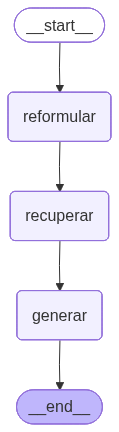


✓ Agente compilado con memoria


In [33]:
grafo = StateGraph(EstadoAgente)

grafo.add_node("reformular", nodo_reformular)
grafo.add_node("recuperar", nodo_recuperar)
grafo.add_node("generar", nodo_generar)

grafo.add_edge(START, "reformular")
grafo.add_edge("reformular", "recuperar")
grafo.add_edge("recuperar", "generar")
grafo.add_edge("generar", END)

memoria = MemorySaver()
agente = grafo.compile(checkpointer=memoria)

# Visualización del grafo
try:
    from IPython.display import Image, display
    display(Image(agente.get_graph().draw_mermaid_png()))
except Exception:
    print(agente.get_graph().draw_ascii())

print("\n✓ Agente compilado con memoria")

---
## PASO 3 — Interacción y ejemplos documentados

In [34]:
# Función de conversación con el agente
def chatear(pregunta: str, thread_id: str = "sesion-01") -> str:
    """Envía una pregunta al agente y devuelve la respuesta."""
    config = {"configurable": {"thread_id": thread_id}}
    resultado = agente.invoke(
        {"mensajes": [HumanMessage(content=pregunta)]},
        config=config,
    )
    return resultado["mensajes"][-1].content

def mostrar_respuesta(pregunta: str, thread_id: str = "sesion-01"):
    """Helper para mostrar pregunta y respuesta con formato."""
    print(f"\n{'='*65}")
    print(f"PREGUNTA: {pregunta}")
    print(f"{'='*65}")
    respuesta = chatear(pregunta, thread_id)
    print(f"\nRESPUESTA:\n{respuesta}")
    return respuesta

print("✓ Funciones de conversación listas")

✓ Funciones de conversación listas


#### Ejemplos documentados (mismo thread para demostrar memoria)

In [18]:
THREAD = "demo-ejemplos"

# Ejemplo 1
mostrar_respuesta("¿Cuántas empresas textiles hay en España y cómo ha evolucionado este número?", THREAD)


PREGUNTA: ¿Cuántas empresas textiles hay en España y cómo ha evolucionado este número?
  [QUERY] Original:    '¿Cuántas empresas textiles hay en España y cómo ha evolucionado este n'
  [QUERY] Reformulada: 'Número de empresas del sector textil y confección en España, censo de '
  [RAG]   6 chunks recuperados

RESPUESTA:
El contexto proporcionado no contiene información sobre el número de empresas textiles en España ni sobre la evolución de dicha cifra.


'El contexto proporcionado no contiene información sobre el número de empresas textiles en España ni sobre la evolución de dicha cifra.'

In [19]:
# Ejemplo 2
mostrar_respuesta("¿Cuáles son los principales resultados financieros de Inditex en 2024?", THREAD)


PREGUNTA: ¿Cuáles son los principales resultados financieros de Inditex en 2024?
  [QUERY] Original:    '¿Cuáles son los principales resultados financieros de Inditex en 2024?'
  [QUERY] Reformulada: '¿Cuáles son los principales resultados financieros, indicadores de ren'
  [RAG]   6 chunks recuperados

RESPUESTA:
Basado en la memoria anual de Inditex 2025, los principales resultados financieros del ejercicio 2024 fueron los siguientes:

*   **Flujos generados** (ajustados por pagos de arrendamiento): 7.684 millones de euros.
*   **Caja generada por las operaciones**: 7.486 millones de euros.
*   **Cash flow libre**: 4.814 millones de euros.
*   **Inversión**: 2.672 millones de euros.
*   **Variación del circulante**: -198 millones de euros.

Adicionalmente, los honorarios totales por servicios de auditoría y relacionados pagados a Ernst & Young ascendieron a 8,1 millones de euros (incluyendo 0,1 millones en servicios fiscales).

[Fuente: memoria_anual_inditex_2025.pdf | p.76, p.64]


'Basado en la memoria anual de Inditex 2025, los principales resultados financieros del ejercicio 2024 fueron los siguientes:\n\n*   **Flujos generados** (ajustados por pagos de arrendamiento): 7.684 millones de euros.\n*   **Caja generada por las operaciones**: 7.486 millones de euros.\n*   **Cash flow libre**: 4.814 millones de euros.\n*   **Inversión**: 2.672 millones de euros.\n*   **Variación del circulante**: -198 millones de euros.\n\nAdicionalmente, los honorarios totales por servicios de auditoría y relacionados pagados a Ernst & Young ascendieron a 8,1 millones de euros (incluyendo 0,1 millones en servicios fiscales).\n\n[Fuente: memoria_anual_inditex_2025.pdf | p.76, p.64]'

In [20]:
# Ejemplo 3
mostrar_respuesta("¿Cuál es la posición de España en el sector textil europeo y cuáles son sus principales mercados de exportación?", THREAD)


PREGUNTA: ¿Cuál es la posición de España en el sector textil europeo y cuáles son sus principales mercados de exportación?
  [QUERY] Original:    '¿Cuál es la posición de España en el sector textil europeo y cuáles so'
  [QUERY] Reformulada: '¿Cuál es el ranking, la cuota de mercado y la competitividad de la ind'
  [RAG]   6 chunks recuperados

RESPUESTA:
Respecto a la posición de España y sus mercados de exportación, la información disponible es la siguiente:

*   **Posición en el sector:** La industria de la moda mantiene un peso relativo "muy destacado" en la economía española, generando el **2,9% del valor añadido bruto**, con una representatividad aún mayor en exportaciones y empleo [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.5]. El objetivo futuro del sector es alcanzar el liderazgo europeo en calidad, innovación, sostenibilidad y responsabilidad social [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.8].
*   **Mercados de exportación:** El contexto 

'Respecto a la posición de España y sus mercados de exportación, la información disponible es la siguiente:\n\n*   **Posición en el sector:** La industria de la moda mantiene un peso relativo "muy destacado" en la economía española, generando el **2,9% del valor añadido bruto**, con una representatividad aún mayor en exportaciones y empleo [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.5]. El objetivo futuro del sector es alcanzar el liderazgo europeo en calidad, innovación, sostenibilidad y responsabilidad social [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.8].\n*   **Mercados de exportación:** El contexto menciona los porcentajes de los principales países de destino de las exportaciones de la industria textil en España, siendo los más relevantes aquellos que concentran el **14,9%, 13,3%, 9,7%, 9,7% y 8,3%** de las exportaciones; sin embargo, el documento no especifica los nombres de dichos países [Fuente: comercio_textil_2024.pdf | p.50].'

In [21]:
# Ejemplo 4 — referencia al contexto de preguntas anteriores (demuestra memoria)
mostrar_respuesta("¿Y qué papel juega Inditex en esas exportaciones de moda española que acabas de mencionar?", THREAD)


PREGUNTA: ¿Y qué papel juega Inditex en esas exportaciones de moda española que acabas de mencionar?
  [QUERY] Original:    '¿Y qué papel juega Inditex en esas exportaciones de moda española que '
  [QUERY] Reformulada: '¿Cuál es la incidencia, el peso estratégico y el impacto del grupo Ind'
  [RAG]   6 chunks recuperados

RESPUESTA:
El contexto proporcionado no contiene información específica sobre el papel cuantitativo o el porcentaje de contribución de Inditex en las exportaciones de moda española. 

Solo se indica que Inditex es una sociedad domiciliada en España y que su actividad se desarrolla a través de diversos formatos comerciales (Zara, Pull&Bear, Massimo Dutti, Bershka, Stradivarius, Oysho, Lefties y Zara Home) operando con un modelo de tiendas y venta online [Fuente: memoria_anual_inditex_2025.pdf | p.25].


'El contexto proporcionado no contiene información específica sobre el papel cuantitativo o el porcentaje de contribución de Inditex en las exportaciones de moda española. \n\nSolo se indica que Inditex es una sociedad domiciliada en España y que su actividad se desarrolla a través de diversos formatos comerciales (Zara, Pull&Bear, Massimo Dutti, Bershka, Stradivarius, Oysho, Lefties y Zara Home) operando con un modelo de tiendas y venta online [Fuente: memoria_anual_inditex_2025.pdf | p.25].'

In [22]:
# Ejemplo 5
mostrar_respuesta("¿Cuál es la balanza comercial del sector textil en España y qué tendencia muestra?", THREAD)


PREGUNTA: ¿Cuál es la balanza comercial del sector textil en España y qué tendencia muestra?
  [QUERY] Original:    '¿Cuál es la balanza comercial del sector textil en España y qué tenden'
  [QUERY] Reformulada: '¿Cuál es la balanza comercial, el saldo de exportaciones e importacion'
  [RAG]   6 chunks recuperados

RESPUESTA:
El contexto proporcionado no contiene los datos específicos sobre el valor total de las exportaciones e importaciones necesarios para calcular la balanza comercial del sector textil en España.

No obstante, se puede extraer la siguiente información relacionada:

*   **Importancia de las exportaciones:** Se indica que la industria de la moda mantiene un peso relativo "muy destacado" en la economía española, siendo su representatividad aún mayor en términos de exportaciones y empleo que en el valor añadido bruto (2,9%) [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.5].
*   **Tendencia industrial:** En cuanto a la tendencia general, se señala que la in

'El contexto proporcionado no contiene los datos específicos sobre el valor total de las exportaciones e importaciones necesarios para calcular la balanza comercial del sector textil en España.\n\nNo obstante, se puede extraer la siguiente información relacionada:\n\n*   **Importancia de las exportaciones:** Se indica que la industria de la moda mantiene un peso relativo "muy destacado" en la economía española, siendo su representatividad aún mayor en términos de exportaciones y empleo que en el valor añadido bruto (2,9%) [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.5].\n*   **Tendencia industrial:** En cuanto a la tendencia general, se señala que la industria manufacturera del textil, calzado y confección española frenó su impulso en el periodo 2023-2024, registrando caídas en empresas, facturación y empleos, situación que parece estarse agravando en 2025 [Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | p.8].'

---
## PASO 4 — Chat interactivo

Celda de conversación libre con el agente. Ejecuta y escribe tu pregunta cuando aparezca el prompt.

In [17]:
# Celda interactiva — escribe 'salir' para terminar
THREAD_CHAT = "chat-interactivo"
print("Agente Textil España — escribe 'salir' para terminar\n")

while True:
    pregunta = input("Tú: ").strip()
    if not pregunta:
        continue
    if pregunta.lower() in ("salir", "exit", "quit"):
        print("Conversación finalizada.")
        break
    respuesta = chatear(pregunta, THREAD_CHAT)
    print(f"\nAgente: {respuesta}\n")

Agente Textil España — escribe 'salir' para terminar

Conversación finalizada.
